In [ ]:
#Autoencoder
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

In [ ]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
print("Before reshape, x_train dim:",x_train.shape)
print("Before reshape, x_test dim:",x_test.shape)
x_train=x_train.reshape(len(x_train),784) #og dataset has each image of 28x28=784.
x_test=x_test.reshape(len(x_test),784) #flattening of image data is being done because a simple autoencoder
#has MLPs for it's encoder and decoder layers, which expect a 1D array as input.
print("After reshape, x_train dim:",x_train.shape)
print("After reshape, x_test dim:",x_test.shape)

Before reshape, x_train dim: (60000, 28, 28)
Before reshape, x_test dim: (10000, 28, 28)
After reshape, x_train dim: (60000, 784)
After reshape, x_test dim: (10000, 784)


In [ ]:
#Shallow Autoencoder
input_img=Input(shape=(784,))
encoder=Dense(64,activation='relu')(input_img)
decoder=Dense(784,activation='sigmoid')(encoder)
shallowAE=Model(input_img,decoder)
shallowAE.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
shallowAE.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=shallowAE.fit(x_train,x_train,epochs=10,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0113 - loss: 0.2433 - val_accuracy: 0.0138 - val_loss: 0.1618
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.0114 - loss: 0.1436 - val_accuracy: 0.0100 - val_loss: 0.1266
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0112 - loss: 0.1182 - val_accuracy: 0.0113 - val_loss: 0.1085
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0111 - loss: 0.1039 - val_accuracy: 0.0126 - val_loss: 0.0976
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0121 - loss: 0.0948 - val_accuracy: 0.0137 - val_loss: 0.0901
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0126 - loss: 0.0885 - val_accuracy: 0.0134 - val_loss: 0.0850
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0125 - loss: 0.0840 - val_accuracy: 0.0129 - val_loss: 0.0814
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.0126 - loss: 0.0810 - val_accu

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

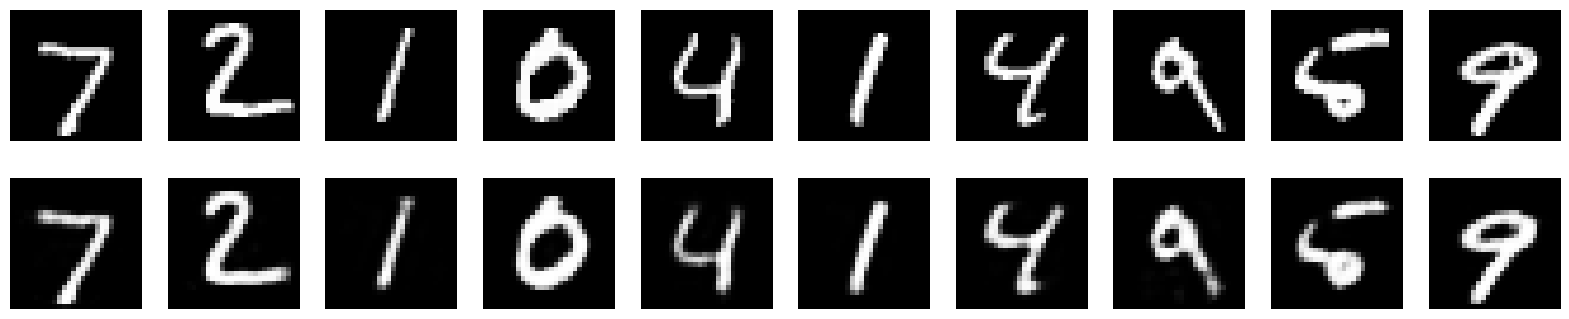

In [ ]:
decoded_img=shallowAE.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
  ax=plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.axis('off')
  ax=plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
  plt.axis('off')
plt.show

In [ ]:
#Deep Autoencoder
input_img=Input(shape=(784,))
encode1=Dense(256,activation='relu')(input_img)
encode2=Dense(128,activation='relu')(encode1)
encode3=Dense(64,activation='relu')(encode2)
decode1=Dense(128,activation='relu')(encode3)
decode2=Dense(256,activation='relu')(decode1)
decode3=Dense(784,activation='sigmoid')(decode2)
deepAE=Model(input_img,decode3)
deepAE.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
deepAE.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=deepAE.fit(x_train,x_train,epochs=10,shuffle=True,batch_size=256,validation_data=(x_test,x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.0107 - loss: 0.2165 - val_accuracy: 0.0090 - val_loss: 0.1390
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0138 - loss: 0.1248 - val_accuracy: 0.0133 - val_loss: 0.1129
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.0124 - loss: 0.1089 - val_accuracy: 0.0090 - val_loss: 0.1038
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.0117 - loss: 0.1013 - val_accuracy: 0.0122 - val_loss: 0.0979
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.0117 - loss: 0.0966 - val_accuracy: 0.0118 - val_loss: 0.0939
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.0113 - loss: 0.0932 - val_accuracy: 0.0128 - val_loss: 0.0908
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0120 - loss: 0.0904 - val_accuracy: 0.0134 - val_loss: 0.0886
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.0120 - loss: 0.0884 - val_ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

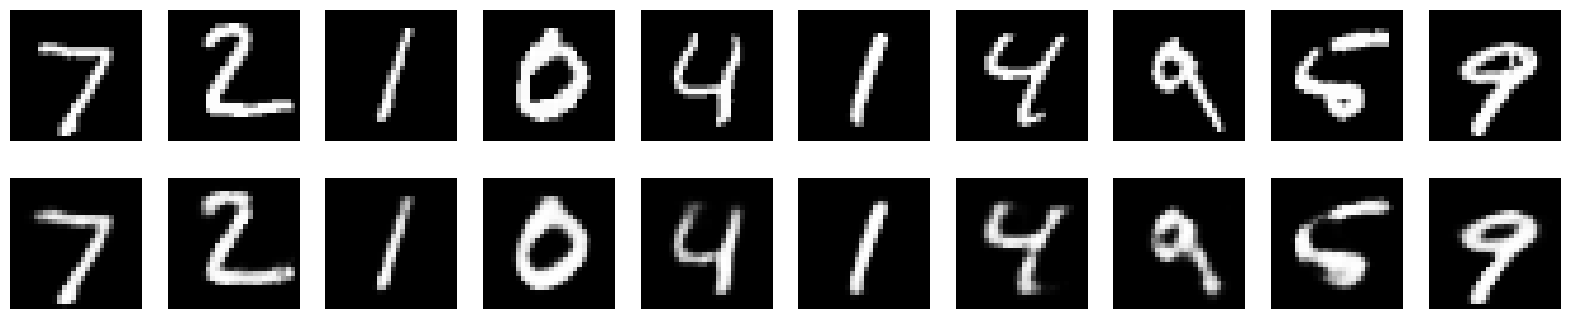

In [ ]:
decoded_img=deepAE.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
  ax=plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.axis('off')
  ax=plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
  plt.axis('off')
plt.show

In [ ]:
from tensorflow.keras import regularizers
#Sparse Autoencoder with l1 regularization (l1 was skipped in theory class)
input_img=Input(shape=(784,))
encoder=Dense(64,activation='relu',activity_regularizer=regularizers.l1(1e-4))(input_img)
decoder=Dense(784,activation='sigmoid')(encoder)
sparseAE=Model(input_img,decoder)
sparseAE.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
sparseAE.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=sparseAE.fit(x_train,x_train,epochs=10,shuffle=True,batch_size=256,validation_data=(x_test,x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0144 - loss: 0.6581 - val_accuracy: 0.0161 - val_loss: 0.6155
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0146 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0150 - loss: 0.5274 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4637
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0150 - loss: 0.4173 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0150 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0150 - loss: 0.3739 - val_accu

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

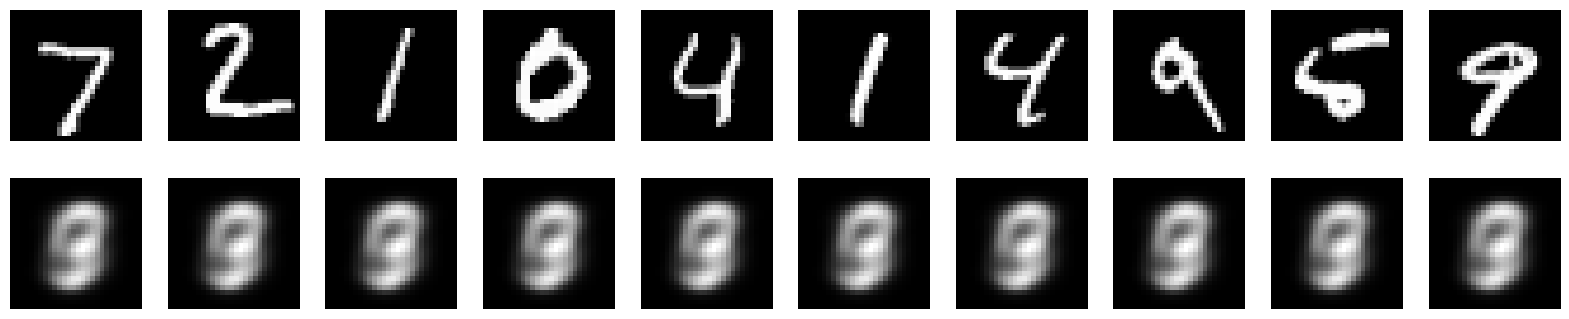

In [ ]:
decoded_img=sparseAE.predict(x_test)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
  ax=plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.axis('off')
  ax=plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
  plt.axis('off')
plt.show

In [ ]:
#denoising autoencoder
noise_factor=0.5
x_train_noisy=x_train+noise_factor*np.random.normal( #gaussian noise? normal distribution?
    loc=0.0,scale=1.0,size=x_train.shape #loc=0 is mean=0, scale=1 is standard deviation=1.
)
x_test_noisy=x_test+noise_factor*np.random.normal(
    loc=0.0,scale=1.0,size=x_test.shape
)
x_train_noisy=np.clip(x_train_noisy,0.,1.)
x_test_noisy=np.clip(x_test_noisy,0.,1.) #values <0 ->0, values >1 ->1, 0<values<1 -> same


In [ ]:
#Denoising Autoencoder
input_img=Input(shape=(784,))
encode1=Dense(256,activation='relu')(input_img)
encode2=Dense(128,activation='relu')(encode1)
encode3=Dense(64,activation='relu')(encode2)
decode1=Dense(128,activation='relu')(encode3)
decode2=Dense(256,activation='relu')(decode1)
decode3=Dense(784,activation='sigmoid')(decode2)
denoiseAE=Model(input_img,decode3)
denoiseAE.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
denoiseAE.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=denoiseAE.fit(x_train_noisy,x_train,epochs=10,shuffle=True,batch_size=256,validation_data=(x_test_noisy,x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.0088 - loss: 0.2483 - val_accuracy: 0.0051 - val_loss: 0.1837
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.0116 - loss: 0.1657 - val_accuracy: 0.0107 - val_loss: 0.1526
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.0123 - loss: 0.1477 - val_accuracy: 0.0109 - val_loss: 0.1414
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0117 - loss: 0.1395 - val_accuracy: 0.0115 - val_loss: 0.1375
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0107 - loss: 0.1335 - val_accuracy: 0.0110 - val_loss: 0.1304
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.0110 - loss: 0.1290 - val_accuracy: 0.0115 - val_loss: 0.1274
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.0121 - loss: 0.1259 - val_accuracy: 0.0146 - val_loss: 0.1245
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.0123 - loss: 0.1232 - val_a

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

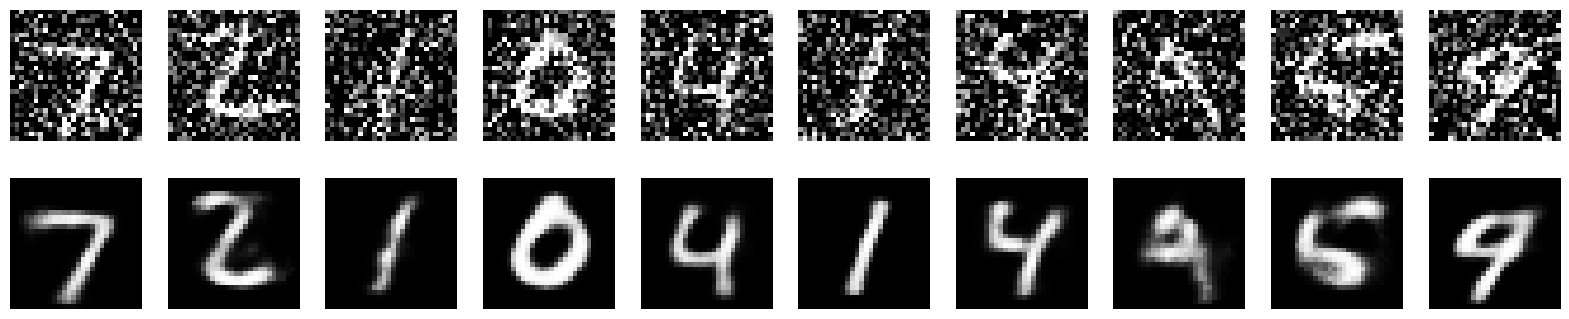

In [ ]:
decoded_img=denoiseAE.predict(x_test_noisy)
n=10
plt.figure(figsize=(20,4))
for i in range(n):
  ax=plt.subplot(2,n,i+1)
  plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
  plt.axis('off')
  ax=plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
  plt.axis('off')
plt.show